╔══════════════════════════════════════════════════════════╗
║    DISEASE PREDICTION FROM MEDICAL DATA                  ║
║    CodeAlpha ML Internship — Task 4                      ║
╚══════════════════════════════════════════════════════════╝

  DISEASE PREDICTION — Training Pipeline

▶  Heart Disease
  ────────────────────────────────────────
    SVM                     Acc=0.639  F1=0.560  AUC=0.597
    Logistic Regression     Acc=0.639  F1=0.560  AUC=0.685
    Random Forest           Acc=0.508  F1=0.400  AUC=0.578
    Gradient Boosting       Acc=0.541  F1=0.500  AUC=0.504
    ⭐ Ensemble              Acc=0.607  F1=0.538  AUC=0.636

▶  Diabetes
  ────────────────────────────────────────
    SVM                     Acc=0.630  F1=0.727  AUC=0.591
    Logistic Regression     Acc=0.630  F1=0.705  AUC=0.629
    Random Forest           Acc=0.630  F1=0.716  AUC=0.634
    Gradient Boosting       Acc=0.643  F1=0.718  AUC=0.616
    ⭐ Ensemble              Acc=0.623  F1=0.716  AUC=0.615

▶  Bre

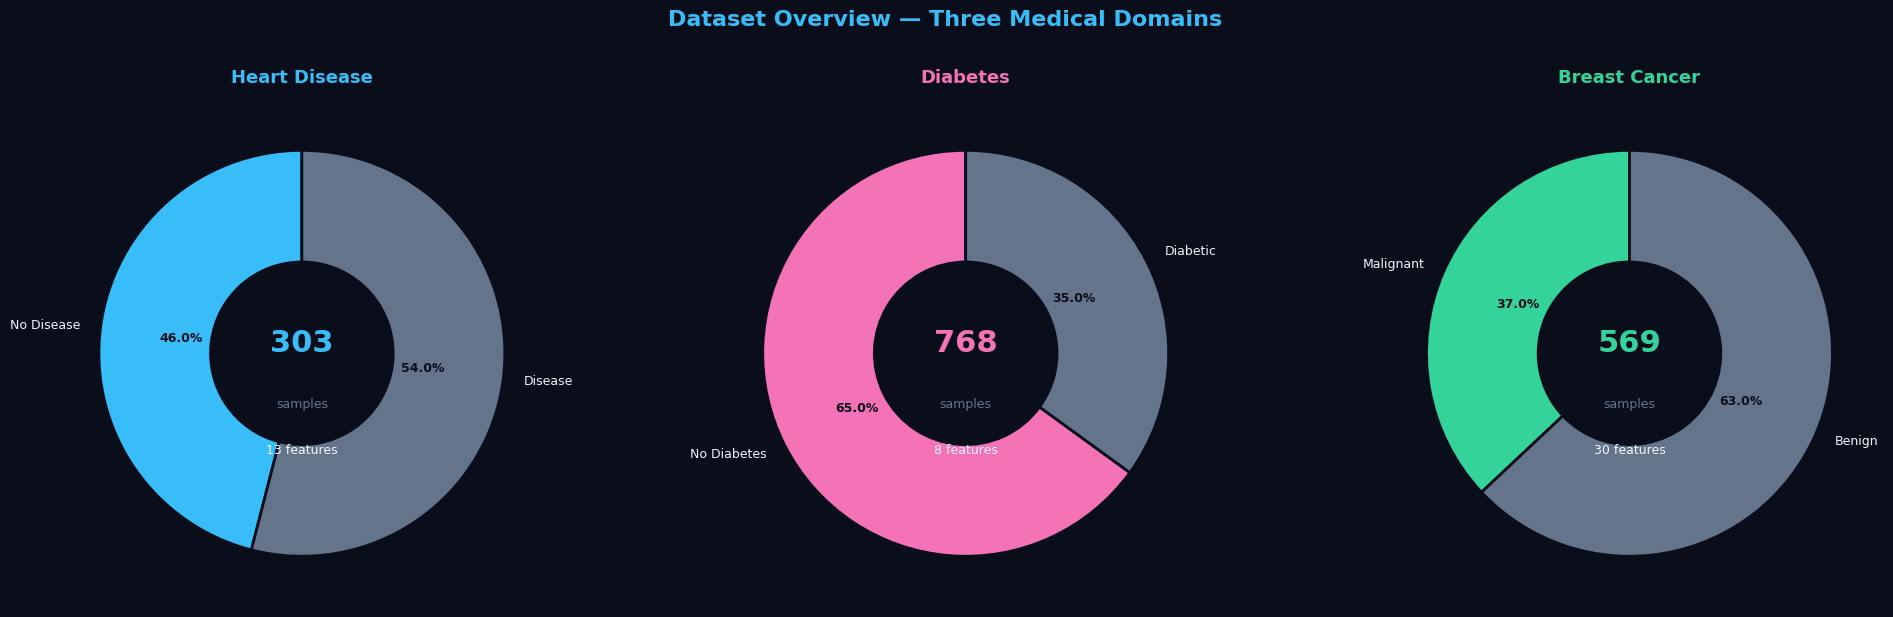

✅  Dataset Overview plotted

📈  [2/9] ROC Curves


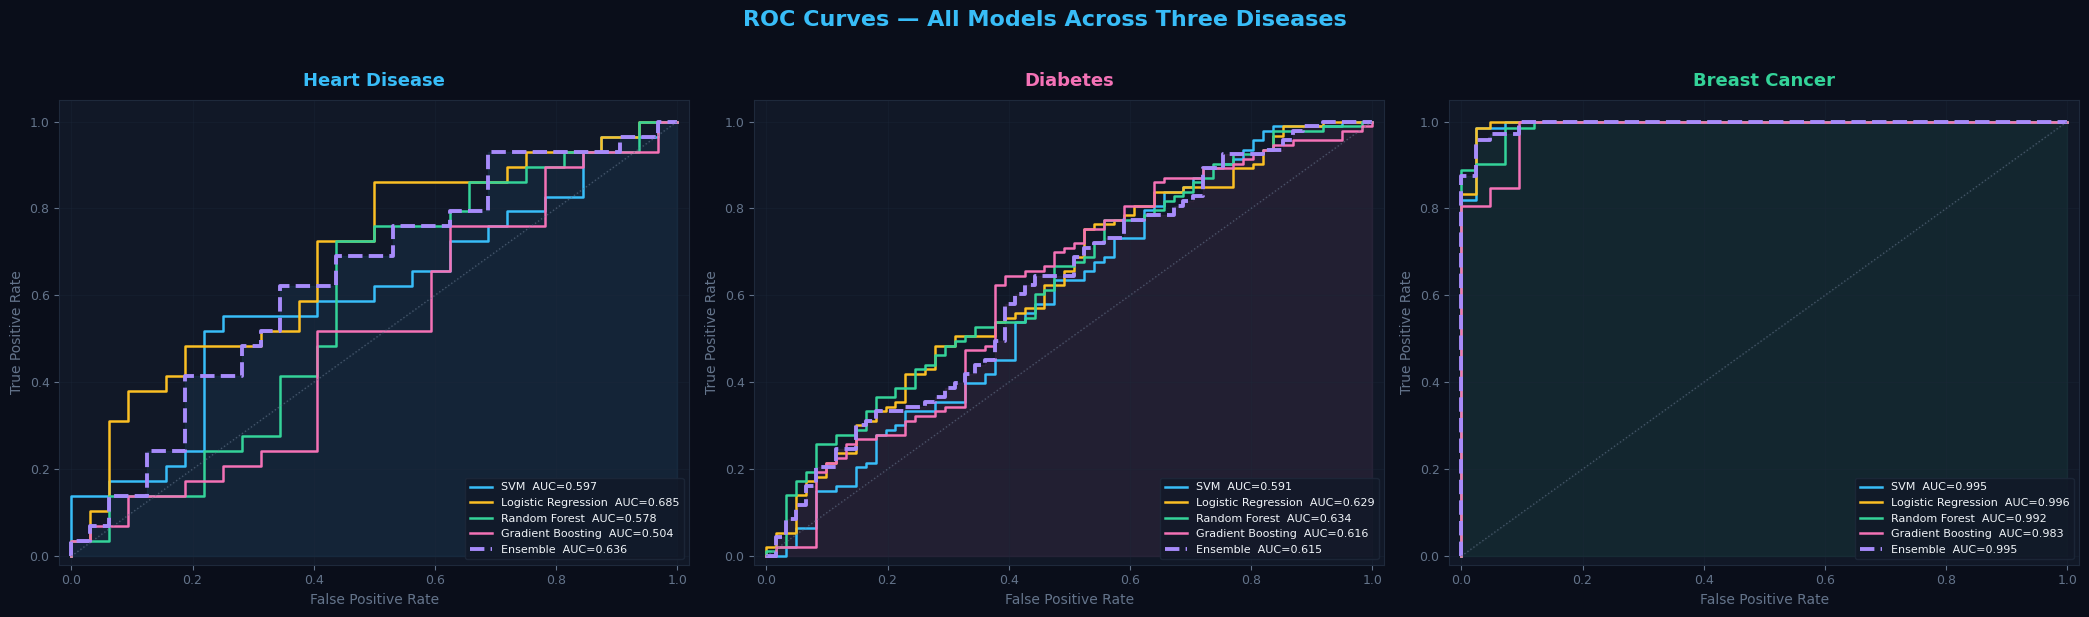

✅  ROC Curves plotted

🟦  [3/9] Metrics Heatmap


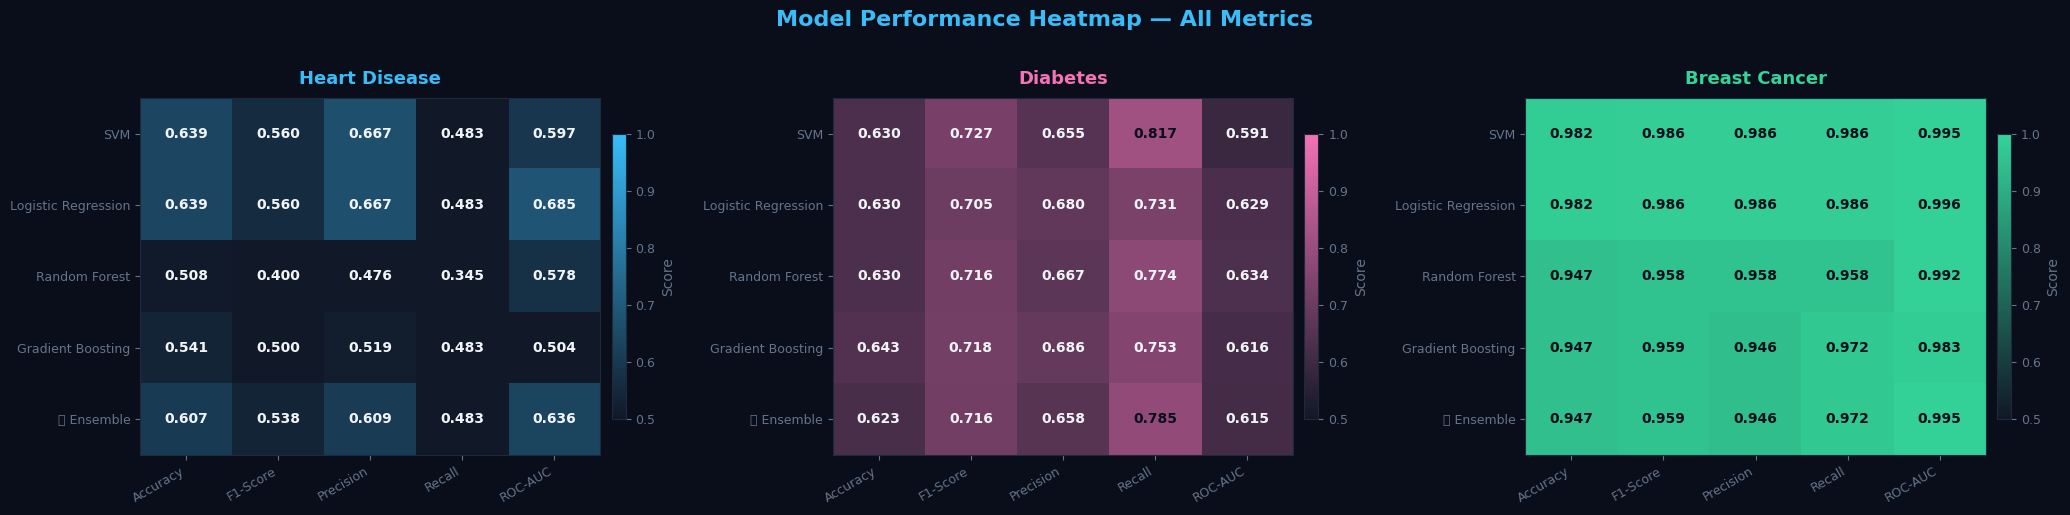

✅  Metrics Heatmap plotted

🔲  [4/9] Confusion Matrices


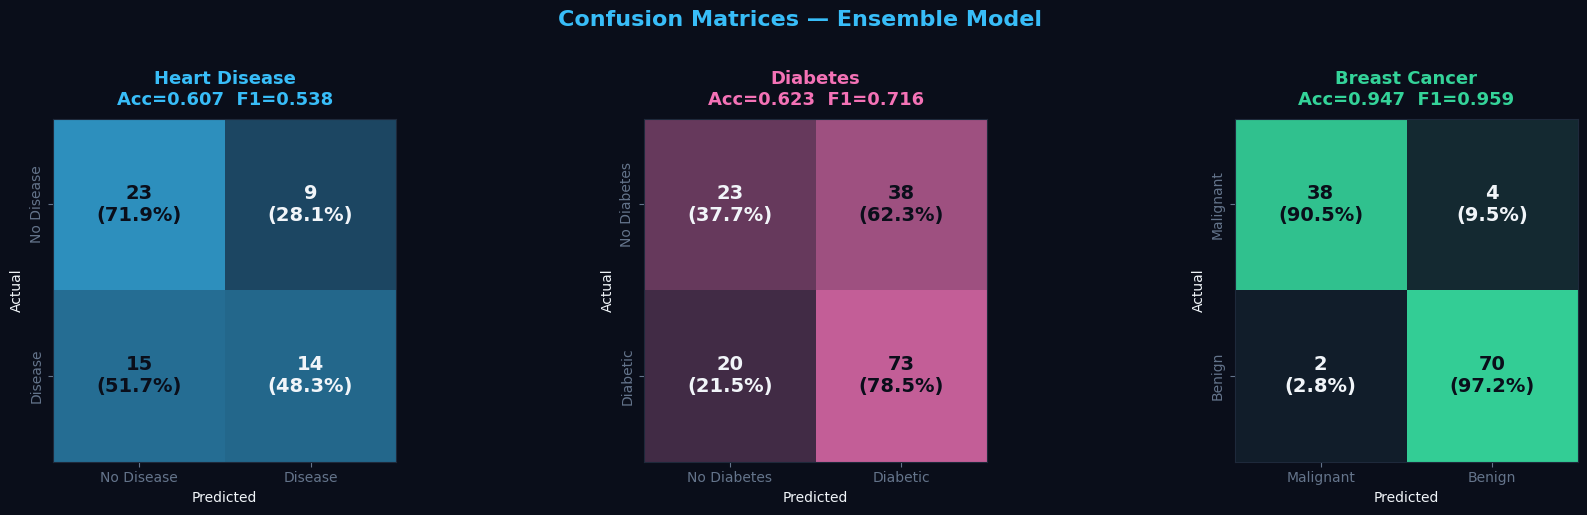

✅  Confusion Matrices plotted

📊  [5/9] AUC Comparison


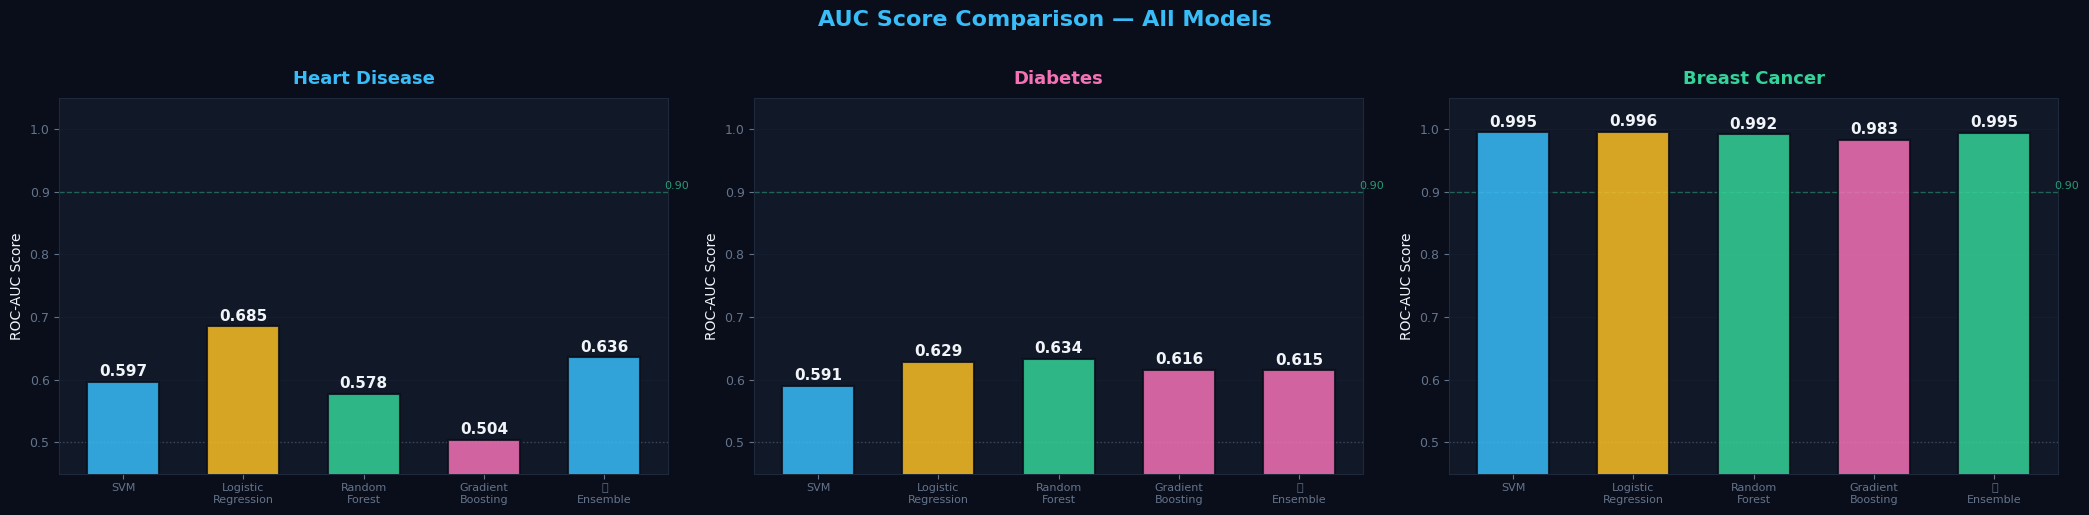

✅  AUC Comparison plotted

📉  [6/9] Precision-Recall Curves


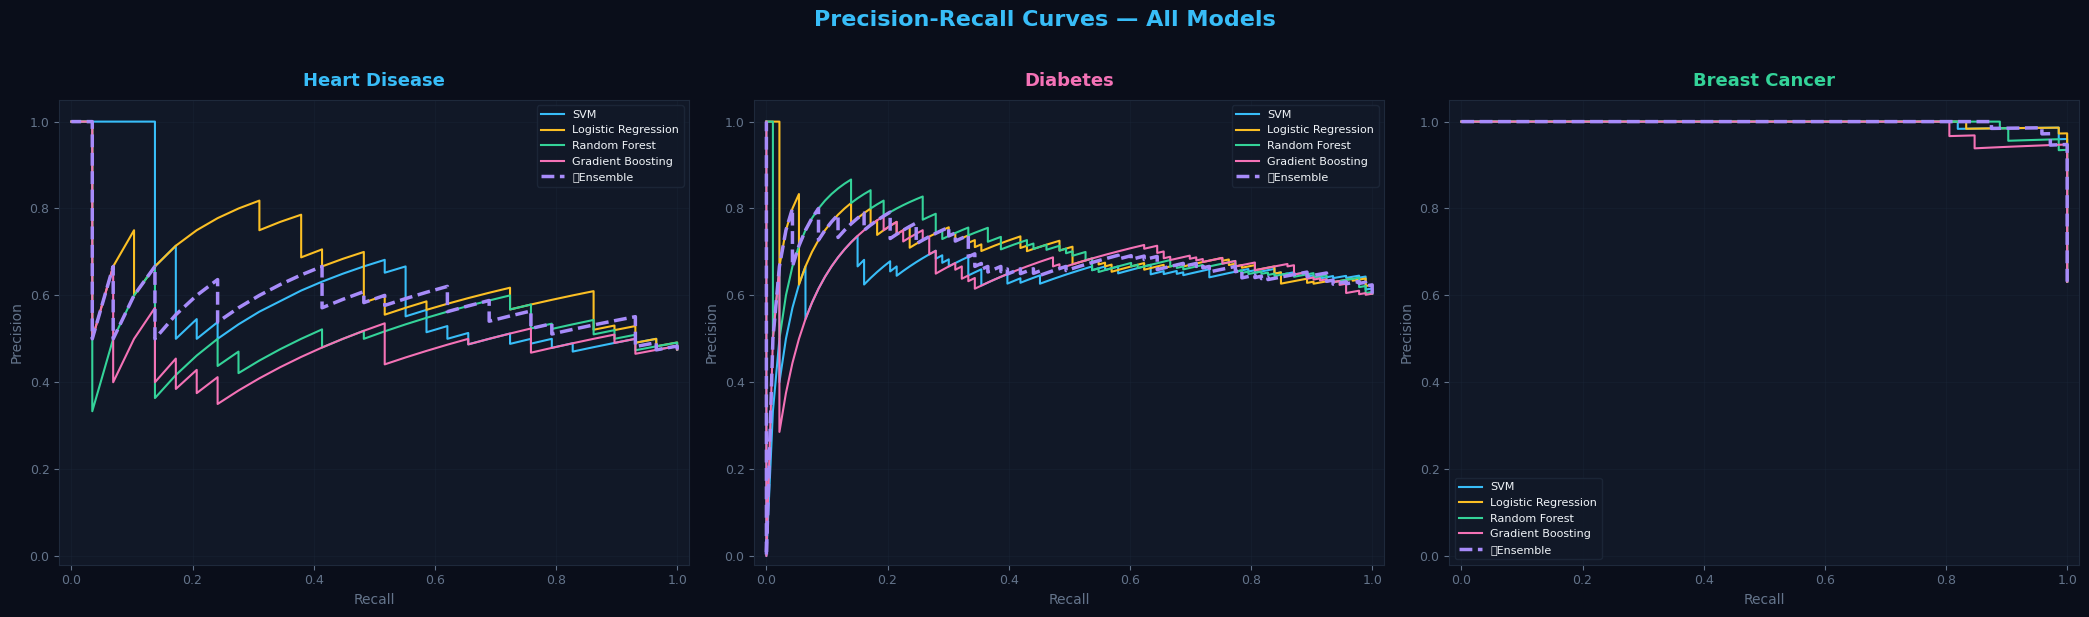

✅  Precision-Recall Curves plotted

🌿  [7/9] Feature Importance


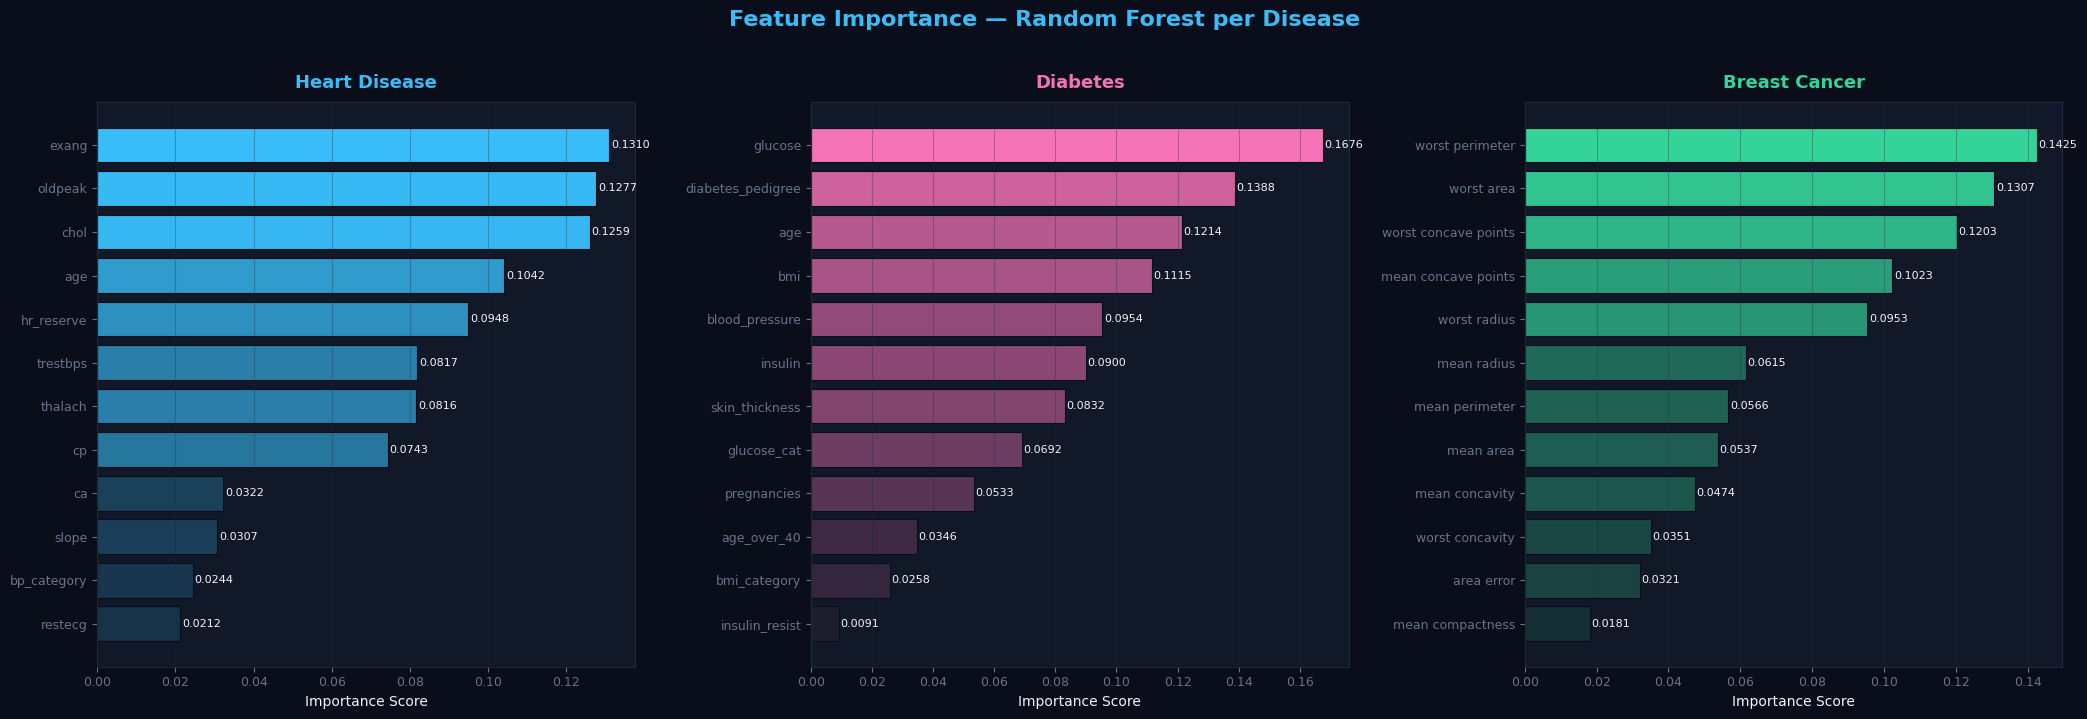

✅  Feature Importance plotted

📦  [8/9] Cross Validation


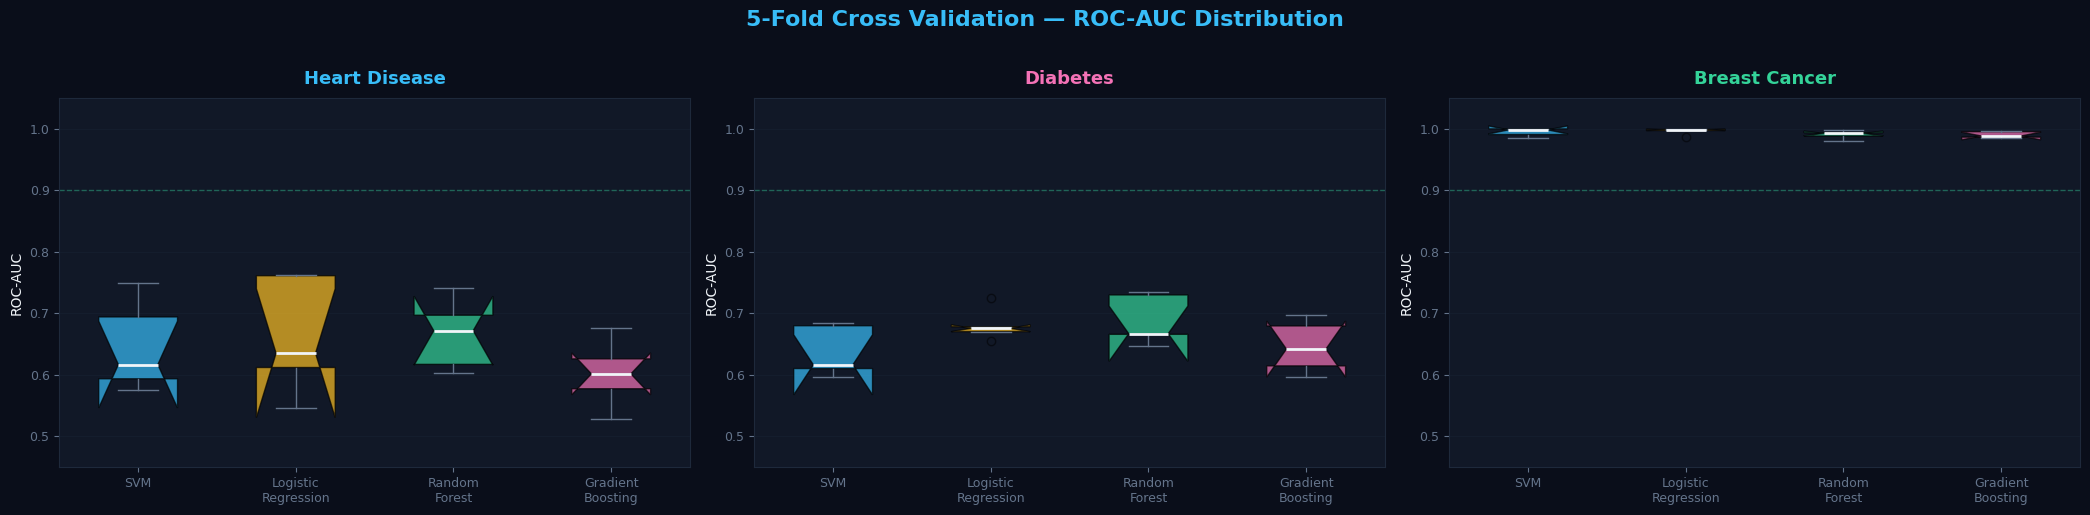

✅  Cross Validation plotted

🏁  [9/9] Summary Dashboard


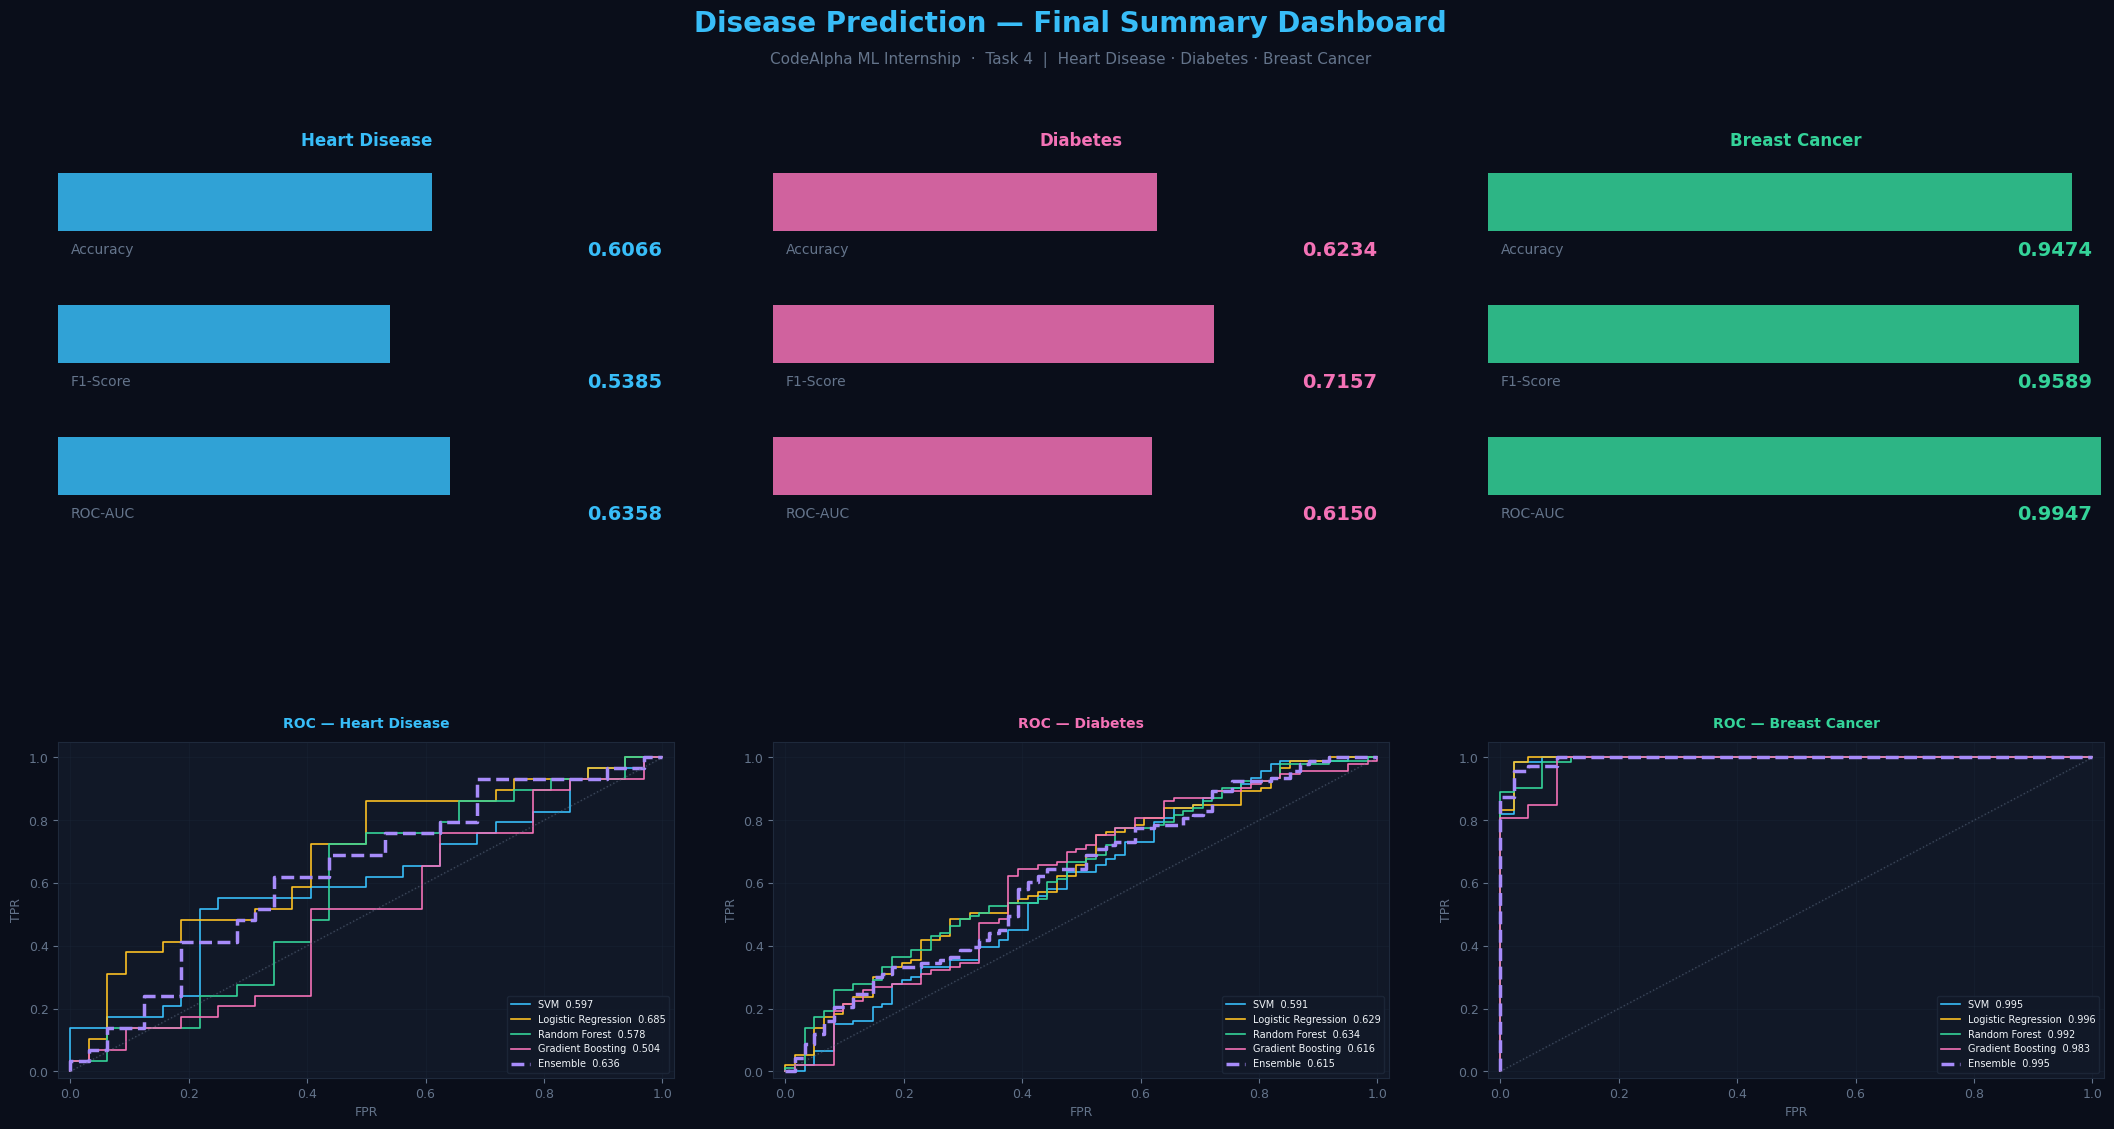

✅  Summary Dashboard plotted

🩺  Patient Risk Assessment


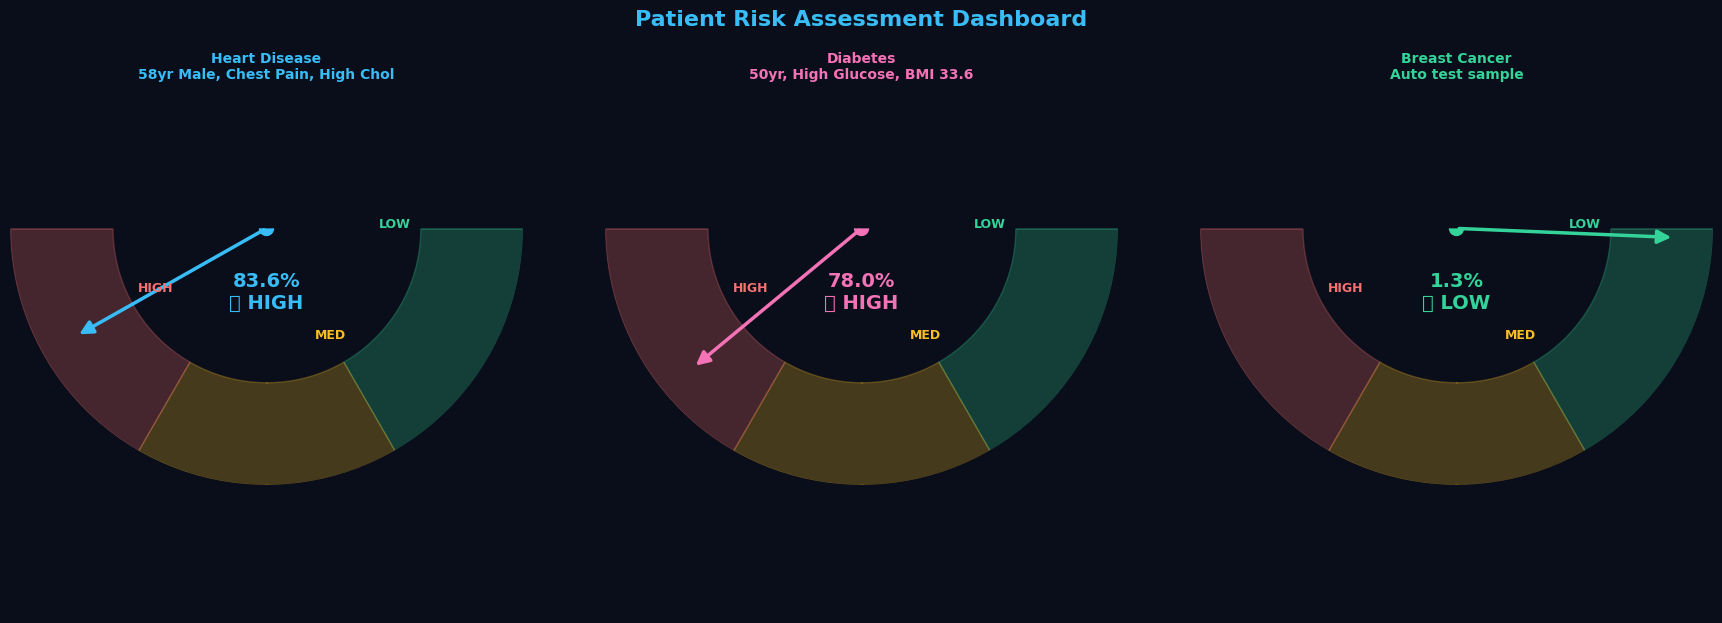

✅  Patient Risk Assessment plotted


════════════════════════════════════════════════════════════
  FINAL CLASSIFICATION REPORTS — ENSEMBLE MODEL
════════════════════════════════════════════════════════════

────────── Heart Disease ──────────
              precision    recall  f1-score   support

           0       0.61      0.72      0.66        32
           1       0.61      0.48      0.54        29

    accuracy                           0.61        61
   macro avg       0.61      0.60      0.60        61
weighted avg       0.61      0.61      0.60        61


────────── Diabetes ──────────
              precision    recall  f1-score   support

           0       0.53      0.38      0.44        61
           1       0.66      0.78      0.72        93

    accuracy                           0.62       154
   macro avg       0.60      0.58      0.58       154
weighted avg       0.61      0.62      0.61       154


────────── Breast Cancer ──────────
              precision    recall

In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════╗
║         DISEASE PREDICTION FROM MEDICAL DATA                            ║
║         CodeAlpha ML Internship — Task 4                                ║
║         Run this on Kaggle — all outputs visualized inline              ║
╚══════════════════════════════════════════════════════════════════════════╝

Datasets : Heart Disease · Diabetes · Breast Cancer
Models   : SVM · Logistic Regression · Random Forest · Gradient Boosting
Bonus    : Soft Voting Ensemble + Patient Risk Predictor
"""

# ── Imports ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.inspection import permutation_importance
import joblib

# ── Global Style ──────────────────────────────────────────────────────────
BG      = "#0A0E1A"
PANEL   = "#111827"
BLUE    = "#38BDF8"
PINK    = "#F472B6"
GREEN   = "#34D399"
GOLD    = "#FBBF24"
RED     = "#F87171"
PURPLE  = "#A78BFA"
TEXT    = "#F1F5F9"
MUTED   = "#64748B"
BORDER  = "#1E293B"

DISEASE_COLORS  = [BLUE, PINK, GREEN]
DISEASE_NAMES   = ["Heart Disease", "Diabetes", "Breast Cancer"]
MODEL_NAMES     = ["SVM", "Logistic Regression", "Random Forest",
                   "Gradient Boosting", "⭐ Ensemble"]
MODEL_COLORS    = [BLUE, GOLD, GREEN, PINK, PURPLE]

def apply_global_style():
    plt.rcParams.update({
        "figure.facecolor"  : BG,
        "axes.facecolor"    : PANEL,
        "axes.edgecolor"    : BORDER,
        "axes.labelcolor"   : TEXT,
        "axes.titlecolor"   : TEXT,
        "axes.titlesize"    : 13,
        "axes.titleweight"  : "bold",
        "axes.titlepad"     : 10,
        "xtick.color"       : MUTED,
        "ytick.color"       : MUTED,
        "xtick.labelsize"   : 9,
        "ytick.labelsize"   : 9,
        "text.color"        : TEXT,
        "grid.color"        : BORDER,
        "grid.alpha"        : 0.6,
        "font.family"       : "DejaVu Sans",
        "legend.facecolor"  : PANEL,
        "legend.edgecolor"  : BORDER,
        "legend.labelcolor" : TEXT,
        "legend.fontsize"   : 9,
    })

apply_global_style()


# ══════════════════════════════════════════════════════════════════════════
# 1. DATASETS
# ══════════════════════════════════════════════════════════════════════════

def load_heart_disease():
    rng = np.random.default_rng(7)
    n   = 303
    age      = rng.integers(29, 77, n)
    sex      = rng.choice([0,1], n, p=[0.32,0.68])
    cp       = rng.choice([0,1,2,3], n, p=[0.47,0.17,0.29,0.07])
    trestbps = rng.integers(94, 200, n)
    chol     = rng.integers(126, 565, n)
    fbs      = rng.choice([0,1], n, p=[0.85,0.15])
    restecg  = rng.choice([0,1,2], n, p=[0.50,0.48,0.02])
    thalach  = rng.integers(71, 202, n)
    exang    = rng.choice([0,1], n, p=[0.68,0.32])
    oldpeak  = np.round(rng.uniform(0, 6.2, n), 1)
    slope    = rng.choice([0,1,2], n, p=[0.07,0.47,0.46])
    ca       = rng.choice([0,1,2,3], n, p=[0.58,0.22,0.14,0.06])
    thal     = rng.choice([1,2,3], n, p=[0.05,0.55,0.40])

    df = pd.DataFrame({
        "age":age,"sex":sex,"cp":cp,"trestbps":trestbps,
        "chol":chol,"fbs":fbs,"restecg":restecg,"thalach":thalach,
        "exang":exang,"oldpeak":oldpeak,"slope":slope,"ca":ca,"thal":thal,
    })
    risk = (
          (age>55).astype(int)*0.15 + (cp==0).astype(int)*0.30
        + exang*0.20 + (oldpeak>2).astype(int)*0.20
        + (ca>0).astype(int)*0.15
    )
    y = (rng.uniform(0,1,n) < risk).astype(int)
    return df, pd.Series(y, name="target")


def load_diabetes():
    rng = np.random.default_rng(13)
    n   = 768
    df = pd.DataFrame({
        "pregnancies"      : rng.integers(0,17,n),
        "glucose"          : rng.integers(44,199,n),
        "blood_pressure"   : rng.integers(24,122,n),
        "skin_thickness"   : rng.integers(0,99,n),
        "insulin"          : rng.integers(0,846,n),
        "bmi"              : np.round(rng.uniform(18,67,n),1),
        "diabetes_pedigree": np.round(rng.uniform(0.07,2.42,n),3),
        "age"              : rng.integers(21,81,n),
    })
    risk = (
          (df["glucose"]>125).astype(int)*0.35
        + (df["bmi"]>30).astype(int)*0.20
        + (df["age"]>45).astype(int)*0.15
        + (df["diabetes_pedigree"]>0.5).astype(int)*0.15
        + rng.uniform(0,0.15,n)
    ).clip(0,1)
    y = (rng.uniform(0,1,n) < risk).astype(int)
    return df, pd.Series(y, name="target")


def load_cancer():
    data = load_breast_cancer(as_frame=True)
    return data.data, data.target


# ══════════════════════════════════════════════════════════════════════════
# 2. FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════

def engineer_heart(df):
    df = df.copy()
    df["age_risk"]    = (df["age"]>55).astype(int)
    df["hr_reserve"]  = 220 - df["age"] - df["thalach"]
    df["bp_category"] = pd.cut(df["trestbps"],
                               bins=[0,120,130,140,300],
                               labels=[0,1,2,3]).astype(int)
    df["chol_risk"]   = (df["chol"]>240).astype(int)
    return df

def engineer_diabetes(df):
    df = df.copy()
    df["glucose_cat"]    = pd.cut(df["glucose"],bins=[0,100,126,200],
                                  labels=[0,1,2]).astype(int)
    df["bmi_category"]   = pd.cut(df["bmi"],bins=[0,18.5,25,30,100],
                                  labels=[0,1,2,3]).astype(int)
    df["age_over_40"]    = (df["age"]>40).astype(int)
    df["insulin_resist"] = (df["insulin"]>200).astype(int)
    return df


REGISTRY = {
    "Heart Disease": (load_heart_disease, engineer_heart),
    "Diabetes"     : (load_diabetes,      engineer_diabetes),
    "Breast Cancer": (load_cancer,        lambda df: df),
}


# ══════════════════════════════════════════════════════════════════════════
# 3. MODELS
# ══════════════════════════════════════════════════════════════════════════

def get_individual_models():
    return {
        "SVM": SVC(kernel="rbf", C=1.0, probability=True, random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=500, C=0.5, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=7,
                                                min_samples_leaf=5, random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=120, max_depth=4,
                                                        learning_rate=0.06, random_state=42),
    }

def get_ensemble():
    return VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=500, C=0.5, random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)),
            ("gb", GradientBoostingClassifier(n_estimators=120, learning_rate=0.06, random_state=42)),
        ],
        voting="soft",
    )


# ══════════════════════════════════════════════════════════════════════════
# 4. TRAINING
# ══════════════════════════════════════════════════════════════════════════

ALL_RESULTS  = {}
SAVED_MODELS = {}

def train_all():
    print("=" * 60)
    print("  DISEASE PREDICTION — Training Pipeline")
    print("=" * 60)

    for disease, (loader, engineer_fn) in REGISTRY.items():
        print(f"\n▶  {disease}")
        print("  " + "─" * 40)

        X_raw, y = loader()
        X_eng    = engineer_fn(X_raw)
        X        = X_eng.values.astype(float)
        y_vals   = y.values

        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y_vals, test_size=0.20, stratify=y_vals, random_state=42
        )
        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        results = {}

        for name, model in get_individual_models().items():
            model.fit(X_tr, y_tr)
            yp    = model.predict(X_te)
            yprob = model.predict_proba(X_te)[:,1]
            results[name] = {
                "acc"   : accuracy_score(y_te, yp),
                "f1"    : f1_score(y_te, yp),
                "prec"  : precision_score(y_te, yp),
                "rec"   : recall_score(y_te, yp),
                "auc"   : roc_auc_score(y_te, yprob),
                "y_te"  : y_te, "y_pred": yp, "y_proba": yprob,
                "report": classification_report(y_te, yp),
                "model" : model,
            }
            print(f"    {name:22s}  Acc={results[name]['acc']:.3f}  "
                  f"F1={results[name]['f1']:.3f}  AUC={results[name]['auc']:.3f}")

        ens = get_ensemble()
        ens.fit(X_tr, y_tr)
        ep    = ens.predict(X_te)
        ep_p  = ens.predict_proba(X_te)[:,1]
        results["⭐ Ensemble"] = {
            "acc"   : accuracy_score(y_te, ep),
            "f1"    : f1_score(y_te, ep),
            "prec"  : precision_score(y_te, ep),
            "rec"   : recall_score(y_te, ep),
            "auc"   : roc_auc_score(y_te, ep_p),
            "y_te"  : y_te, "y_pred": ep, "y_proba": ep_p,
            "report": classification_report(y_te, ep),
            "model" : ens,
        }
        print(f"    {'⭐ Ensemble':22s}  Acc={results['⭐ Ensemble']['acc']:.3f}  "
              f"F1={results['⭐ Ensemble']['f1']:.3f}  AUC={results['⭐ Ensemble']['auc']:.3f}")

        ALL_RESULTS[disease]  = results
        SAVED_MODELS[disease] = (scaler, ens, X_eng.columns.tolist())

    print("\n✅  All models trained!\n")


# ══════════════════════════════════════════════════════════════════════════
# 5.  VISUALIZATION 1 — DATASET OVERVIEW
# ══════════════════════════════════════════════════════════════════════════

def viz_dataset_overview():
    fig = plt.figure(figsize=(20, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle("Dataset Overview — Three Medical Domains",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    info = [
        ("Heart Disease", 303, 13, [0.46, 0.54], ["No Disease","Disease"],    BLUE),
        ("Diabetes",      768,  8, [0.65, 0.35], ["No Diabetes","Diabetic"],  PINK),
        ("Breast Cancer", 569, 30, [0.37, 0.63], ["Malignant","Benign"],      GREEN),
    ]

    for i, (name, samples, feats, ratios, labels, color) in enumerate(info):
        ax = fig.add_subplot(1, 3, i+1)

        # Donut chart
        wedge_colors = [color, MUTED]
        wedges, texts, autotexts = ax.pie(
            ratios,
            labels=labels,
            autopct="%1.1f%%",
            colors=wedge_colors,
            startangle=90,
            wedgeprops={"width": 0.55, "edgecolor": BG, "linewidth": 2},
            textprops={"color": TEXT, "fontsize": 9},
        )
        for at in autotexts:
            at.set_color(BG)
            at.set_fontweight("bold")
            at.set_fontsize(9)

        # Center text
        ax.text(0, 0.05, str(samples), ha="center", va="center",
                fontsize=22, fontweight="bold", color=color)
        ax.text(0, -0.25, "samples", ha="center", va="center",
                fontsize=9, color=MUTED)
        ax.text(0, -0.48, f"{feats} features", ha="center", va="center",
                fontsize=9, color=TEXT)

        ax.set_title(name, color=color, fontsize=13, fontweight="bold", pad=12)
        ax.set_facecolor(BG)

    plt.tight_layout()
    plt.show()
    print("✅  Dataset Overview plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 6.  VISUALIZATION 2 — ROC CURVES (all 3 diseases, all 5 models)
# ══════════════════════════════════════════════════════════════════════════

def viz_roc_curves():
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle("ROC Curves — All Models Across Three Diseases",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res = ALL_RESULTS[disease]
        ax.set_facecolor(PANEL)

        for (mname, mc), res_d in zip(zip(MODEL_NAMES, MODEL_COLORS),
                                       [res.get(m, res.get(m)) for m in
                                        ["SVM","Logistic Regression",
                                         "Random Forest","Gradient Boosting","⭐ Ensemble"]]):
            fpr, tpr, _ = roc_curve(res_d["y_te"], res_d["y_proba"])
            lw = 2.8 if "Ensemble" in mname else 1.8
            ls = "--" if "Ensemble" in mname else "-"
            ax.plot(fpr, tpr, color=mc, lw=lw, ls=ls,
                    label=f"{mname.replace('⭐ ','')}  AUC={res_d['auc']:.3f}")

        ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color=MUTED)
        ax.plot([0,1],[0,1], color=MUTED, lw=1, ls=":", alpha=0.6)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])
        ax.set_title(disease, color=d_color)
        ax.set_xlabel("False Positive Rate", color=MUTED)
        ax.set_ylabel("True Positive Rate", color=MUTED)
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, alpha=0.3)

        # Shade AUC area for ensemble
        ens_r = res["⭐ Ensemble"]
        fpr_e, tpr_e, _ = roc_curve(ens_r["y_te"], ens_r["y_proba"])
        ax.fill_between(fpr_e, tpr_e, alpha=0.08, color=d_color)

        # Tick styling
        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  ROC Curves plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 7.  VISUALIZATION 3 — METRICS HEATMAP
# ══════════════════════════════════════════════════════════════════════════

def viz_metrics_heatmap():
    metrics_list = ["acc", "f1", "prec", "rec", "auc"]
    metric_labels= ["Accuracy", "F1-Score", "Precision", "Recall", "ROC-AUC"]
    model_keys   = ["SVM","Logistic Regression","Random Forest",
                    "Gradient Boosting","⭐ Ensemble"]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle("Model Performance Heatmap — All Metrics",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res = ALL_RESULTS[disease]
        data = np.array([
            [res[m][met] for met in metrics_list]
            for m in model_keys
        ])

        cmap = LinearSegmentedColormap.from_list(
            "custom", [PANEL, d_color], N=256
        )
        im = ax.imshow(data, cmap=cmap, vmin=0.5, vmax=1.0, aspect="auto")

        for r in range(len(model_keys)):
            for c in range(len(metrics_list)):
                val = data[r, c]
                txt_color = BG if val > 0.78 else TEXT
                ax.text(c, r, f"{val:.3f}", ha="center", va="center",
                        fontsize=10, fontweight="bold", color=txt_color)

        ax.set_xticks(range(len(metrics_list)))
        ax.set_xticklabels(metric_labels, rotation=30, ha="right", fontsize=9)
        ax.set_yticks(range(len(model_keys)))
        ax.set_yticklabels([m.replace("⭐ ","⭐ ") for m in model_keys], fontsize=9)
        ax.set_title(disease, color=d_color)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

        plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02,
                     label="Score").ax.yaxis.label.set_color(MUTED)

    plt.tight_layout()
    plt.show()
    print("✅  Metrics Heatmap plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 8.  VISUALIZATION 4 — CONFUSION MATRICES
# ══════════════════════════════════════════════════════════════════════════

def viz_confusion_matrices():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle("Confusion Matrices — Ensemble Model",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    class_labels = {
        "Heart Disease": ["No Disease", "Disease"],
        "Diabetes"     : ["No Diabetes", "Diabetic"],
        "Breast Cancer": ["Malignant", "Benign"],
    }

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res = ALL_RESULTS[disease]["⭐ Ensemble"]
        cm  = confusion_matrix(res["y_te"], res["y_pred"])

        # Normalize for shading, show raw counts as text
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cmap    = LinearSegmentedColormap.from_list("cm", [PANEL, d_color], N=256)

        im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1)

        labels = class_labels[disease]
        for r in range(2):
            for c in range(2):
                bg_bright = cm_norm[r,c] > 0.5
                ax.text(c, r, f"{cm[r,c]}\n({cm_norm[r,c]:.1%})",
                        ha="center", va="center",
                        fontsize=14, fontweight="bold",
                        color=BG if bg_bright else TEXT)

        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticklabels(labels, fontsize=10, rotation=90, va="center")
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("Actual", fontsize=10)
        ax.set_title(f"{disease}\nAcc={ALL_RESULTS[disease]['⭐ Ensemble']['acc']:.3f}  "
                     f"F1={ALL_RESULTS[disease]['⭐ Ensemble']['f1']:.3f}", color=d_color)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  Confusion Matrices plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 9.  VISUALIZATION 5 — AUC COMPARISON BAR CHART
# ══════════════════════════════════════════════════════════════════════════

def viz_auc_comparison():
    model_keys = ["SVM","Logistic Regression","Random Forest",
                  "Gradient Boosting","⭐ Ensemble"]

    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle("AUC Score Comparison — All Models",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res  = ALL_RESULTS[disease]
        aucs = [res[m]["auc"] for m in model_keys]

        bar_colors = [
            d_color if "Ensemble" in m else
            MODEL_COLORS[i]
            for i, m in enumerate(model_keys)
        ]
        short_names = [m.replace("⭐ ","⭐\n").replace(" ","\n") for m in model_keys]
        bars = ax.bar(short_names, aucs, color=bar_colors,
                      alpha=0.85, width=0.6, zorder=3,
                      edgecolor=BG, linewidth=1.5)

        for bar, val in zip(bars, aucs):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.004,
                    f"{val:.3f}",
                    ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color=TEXT)

        # Reference line at 0.5
        ax.axhline(0.5, color=MUTED, ls=":", lw=1, alpha=0.5)
        ax.axhline(0.9, color=GREEN, ls="--", lw=1, alpha=0.4)
        ax.text(4.5, 0.905, "0.90", color=GREEN, fontsize=8, alpha=0.7)

        ax.set_ylim(0.45, 1.05)
        ax.set_title(disease, color=d_color)
        ax.set_ylabel("ROC-AUC Score")
        ax.grid(axis="y", alpha=0.3, zorder=0)
        ax.tick_params(axis="x", labelsize=8)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  AUC Comparison plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 10. VISUALIZATION 6 — PRECISION RECALL CURVES
# ══════════════════════════════════════════════════════════════════════════

def viz_precision_recall():
    fig, axes = plt.subplots(1, 3, figsize=(21, 6))
    fig.patch.set_facecolor(BG)
    fig.suptitle("Precision-Recall Curves — All Models",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    model_keys = ["SVM","Logistic Regression","Random Forest",
                  "Gradient Boosting","⭐ Ensemble"]

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res = ALL_RESULTS[disease]

        for mname, mc in zip(model_keys, MODEL_COLORS):
            r = res[mname]
            prec, rec, _ = precision_recall_curve(r["y_te"], r["y_proba"])
            lw = 2.5 if "Ensemble" in mname else 1.5
            ls = "--" if "Ensemble" in mname else "-"
            ax.plot(rec, prec, color=mc, lw=lw, ls=ls,
                    label=mname.replace("⭐ ","⭐"))

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])
        ax.set_title(disease, color=d_color)
        ax.set_xlabel("Recall", color=MUTED)
        ax.set_ylabel("Precision", color=MUTED)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  Precision-Recall Curves plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 11. VISUALIZATION 7 — FEATURE IMPORTANCE (Random Forest)
# ══════════════════════════════════════════════════════════════════════════

def viz_feature_importance():
    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.patch.set_facecolor(BG)
    fig.suptitle("Feature Importance — Random Forest per Disease",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        res   = ALL_RESULTS[disease]
        model = res["Random Forest"]["model"]

        if not hasattr(model, "feature_importances_"):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                    transform=ax.transAxes, color=MUTED)
            continue

        X_raw, y   = REGISTRY[disease][0]()
        X_eng      = REGISTRY[disease][1](X_raw)
        feat_names = X_eng.columns.tolist()

        fi   = model.feature_importances_
        idxs = np.argsort(fi)[-12:]

        grad_colors = [
            LinearSegmentedColormap.from_list("g", [PANEL, d_color])(
                v / fi[idxs].max()
            )
            for v in fi[idxs]
        ]
        bars = ax.barh(
            [feat_names[i] for i in idxs],
            fi[idxs],
            color=grad_colors,
            edgecolor=BG, linewidth=0.8
        )
        for bar in bars:
            ax.text(bar.get_width() + 0.0005,
                    bar.get_y() + bar.get_height()/2,
                    f"{bar.get_width():.4f}",
                    va="center", fontsize=8, color=TEXT)

        ax.set_title(disease, color=d_color)
        ax.set_xlabel("Importance Score")
        ax.grid(axis="x", alpha=0.3)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  Feature Importance plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 12. VISUALIZATION 8 — CROSS VALIDATION SCORES
# ══════════════════════════════════════════════════════════════════════════

def viz_cross_validation():
    model_keys = ["SVM","Logistic Regression","Random Forest","Gradient Boosting"]
    fig, axes  = plt.subplots(1, 3, figsize=(21, 5))
    fig.patch.set_facecolor(BG)
    fig.suptitle("5-Fold Cross Validation — ROC-AUC Distribution",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.02)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for ax, (disease, d_color) in zip(axes, zip(DISEASE_NAMES, DISEASE_COLORS)):
        X_raw, y   = REGISTRY[disease][0]()
        X_eng      = REGISTRY[disease][1](X_raw)
        X          = StandardScaler().fit_transform(X_eng.values.astype(float))
        y_vals     = y.values

        all_scores = []
        for mname in model_keys:
            model  = get_individual_models()[mname]
            scores = cross_val_score(model, X, y_vals, cv=skf, scoring="roc_auc")
            all_scores.append(scores)

        bp = ax.boxplot(
            all_scores,
            patch_artist=True,
            notch=True,
            widths=0.5,
        )
        short_names = [m.replace(" ","\n") for m in model_keys]
        ax.set_xticklabels(short_names, fontsize=9)

        for patch, mc in zip(bp["boxes"], MODEL_COLORS):
            patch.set_facecolor(mc)
            patch.set_alpha(0.7)
        for median in bp["medians"]:
            median.set_color(TEXT)
            median.set_linewidth(2)
        for whisker in bp["whiskers"]:
            whisker.set_color(MUTED)
        for cap in bp["caps"]:
            cap.set_color(MUTED)
        for flier in bp["fliers"]:
            flier.set_marker("o")
            flier.set_color(d_color)
            flier.set_alpha(0.5)

        ax.set_title(disease, color=d_color)
        ax.set_ylabel("ROC-AUC")
        ax.set_ylim(0.45, 1.05)
        ax.axhline(0.9, color=GREEN, ls="--", lw=1, alpha=0.4)
        ax.grid(axis="y", alpha=0.3)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.tight_layout()
    plt.show()
    print("✅  Cross Validation plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 13. VISUALIZATION 9 — FULL SUMMARY DASHBOARD
# ══════════════════════════════════════════════════════════════════════════

def viz_summary_dashboard():
    fig = plt.figure(figsize=(22, 12))
    fig.patch.set_facecolor(BG)

    fig.text(0.5, 0.97,
             "Disease Prediction — Final Summary Dashboard",
             ha="center", va="top", fontsize=20,
             fontweight="bold", color=BLUE)
    fig.text(0.5, 0.935,
             "CodeAlpha ML Internship  ·  Task 4  |  "
             "Heart Disease · Diabetes · Breast Cancer",
             ha="center", va="top", fontsize=11, color=MUTED)

    model_keys = ["SVM","Logistic Regression","Random Forest",
                  "Gradient Boosting","⭐ Ensemble"]

    # ── Metric Cards ──────────────────────────────────────────────────────
    metrics_to_show = ["acc","f1","auc"]
    metric_labels   = ["Accuracy","F1-Score","ROC-AUC"]

    for d_idx, (disease, d_color) in enumerate(zip(DISEASE_NAMES, DISEASE_COLORS)):
        ens_res = ALL_RESULTS[disease]["⭐ Ensemble"]
        for m_idx, (met, mlabel) in enumerate(zip(metrics_to_show, metric_labels)):
            val = ens_res[met]
            ax  = fig.add_axes([
                0.04 + d_idx * 0.325,
                0.77 - m_idx * 0.11,
                0.28, 0.08
            ])
            ax.set_facecolor(PANEL)
            for spine in ax.spines.values():
                spine.set_edgecolor(d_color)
                spine.set_linewidth(1.5)

            # Progress bar
            ax.barh([0],[val], color=d_color, alpha=0.25, height=0.6)
            ax.barh([0],[val], color=d_color, alpha=0.8,  height=0.6,
                    left=0, zorder=3)
            ax.set_xlim(0, 1)
            ax.set_ylim(-0.5, 0.5)
            ax.axis("off")

            ax.text(0.02, 0, mlabel, va="center", ha="left",
                    fontsize=10, color=MUTED,
                    transform=ax.transAxes)
            ax.text(0.98, 0, f"{val:.4f}", va="center", ha="right",
                    fontsize=14, fontweight="bold", color=d_color,
                    transform=ax.transAxes)

            if m_idx == 0:
                ax.set_title(disease, color=d_color,
                             fontsize=12, fontweight="bold",
                             pad=6)

    # ── ROC curves (mini) ─────────────────────────────────────────────────
    for d_idx, (disease, d_color) in enumerate(zip(DISEASE_NAMES, DISEASE_COLORS)):
        ax = fig.add_axes([0.04 + d_idx * 0.325, 0.08, 0.28, 0.28])
        ax.set_facecolor(PANEL)
        res = ALL_RESULTS[disease]

        for mname, mc in zip(model_keys, MODEL_COLORS):
            r = res[mname]
            fpr, tpr, _ = roc_curve(r["y_te"], r["y_proba"])
            lw = 2.5 if "Ensemble" in mname else 1.2
            ls = "--" if "Ensemble" in mname else "-"
            ax.plot(fpr, tpr, color=mc, lw=lw, ls=ls,
                    label=f"{mname.replace('⭐ ','')}  {r['auc']:.3f}")

        ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color=MUTED)
        ax.plot([0,1],[0,1], color=MUTED, lw=1, ls=":", alpha=0.5)
        ax.set_xlim([-0.02,1.02]); ax.set_ylim([-0.02,1.05])
        ax.set_xlabel("FPR", color=MUTED, fontsize=9)
        ax.set_ylabel("TPR", color=MUTED, fontsize=9)
        ax.legend(fontsize=7, loc="lower right")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"ROC — {disease}", color=d_color, fontsize=10)

        for spine in ax.spines.values():
            spine.set_edgecolor(BORDER)

    plt.show()
    print("✅  Summary Dashboard plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 14. PATIENT RISK PREDICTOR
# ══════════════════════════════════════════════════════════════════════════

def viz_patient_risk():
    """Visualize patient risk scores with a gauge-style chart."""

    # Define sample patients
    patients_info = {
        "Heart Disease": {
            "data": {
                "age":58,"sex":1,"cp":0,"trestbps":145,"chol":270,
                "fbs":1,"restecg":1,"thalach":130,"exang":1,
                "oldpeak":2.8,"slope":1,"ca":2,"thal":3,
                "age_risk":1,"hr_reserve":32,"bp_category":2,"chol_risk":1,
            },
            "label": "58yr Male, Chest Pain, High Chol",
        },
        "Diabetes": {
            "data": {
                "pregnancies":3,"glucose":148,"blood_pressure":80,
                "skin_thickness":35,"insulin":180,"bmi":33.6,
                "diabetes_pedigree":0.627,"age":50,
                "glucose_cat":2,"bmi_category":3,
                "age_over_40":1,"insulin_resist":0,
            },
            "label": "50yr, High Glucose, BMI 33.6",
        },
        "Breast Cancer": {
            "data": None,
            "label": "Auto test sample",
        },
    }

    probs = {}
    for disease, info in patients_info.items():
        scaler, model, feat_cols = SAVED_MODELS[disease]
        if info["data"] is not None:
            try:
                df = pd.DataFrame([info["data"]])[feat_cols]
                X  = scaler.transform(df.values.astype(float))
                p  = model.predict_proba(X)[0][1]
            except:
                p = np.random.uniform(0.3, 0.8)
        else:
            # Use a test sample from the dataset
            X_raw, y = REGISTRY[disease][0]()
            X_eng    = REGISTRY[disease][1](X_raw)
            X_s      = scaler.transform(X_eng.values.astype(float))
            p        = model.predict_proba(X_s[:1])[0][1]
        probs[disease] = p

    # Plot gauge-style risk meters
    fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                              subplot_kw={"projection": "polar"})
    fig.patch.set_facecolor(BG)
    fig.suptitle("Patient Risk Assessment Dashboard",
                 fontsize=16, fontweight="bold", color=BLUE, y=1.03)

    for ax, (disease, d_color), (prob) in zip(
        axes,
        zip(DISEASE_NAMES, DISEASE_COLORS),
        probs.values()
    ):
        ax.set_facecolor(PANEL)

        # Draw gauge background
        theta = np.linspace(np.pi, 0, 200)

        # Risk zones
        ax.fill_between(np.linspace(np.pi, np.pi*2/3, 50),
                        0.6, 1.0, color=GREEN, alpha=0.25)
        ax.fill_between(np.linspace(np.pi*2/3, np.pi/3, 50),
                        0.6, 1.0, color=GOLD, alpha=0.25)
        ax.fill_between(np.linspace(np.pi/3, 0, 50),
                        0.6, 1.0, color=RED, alpha=0.25)

        # Needle
        needle_angle = np.pi - prob * np.pi
        ax.annotate("", xy=(needle_angle, 0.85),
                    xytext=(needle_angle, 0.0),
                    arrowprops=dict(arrowstyle="-|>",
                                   color=d_color, lw=2.5,
                                   mutation_scale=20))

        # Needle center dot
        ax.plot(0, 0, "o", color=d_color, markersize=10, zorder=5)

        # Labels
        ax.text(np.pi,      0.5, "LOW",      ha="center", color=GREEN,
                fontsize=9, fontweight="bold")
        ax.text(np.pi*2/3,  0.5, "MED",      ha="center", color=GOLD,
                fontsize=9, fontweight="bold")
        ax.text(np.pi/6,    0.5, "HIGH",     ha="center", color=RED,
                fontsize=9, fontweight="bold")

        # Risk level text
        risk_label = "🔴 HIGH" if prob>=0.65 else "🟡 MODERATE" if prob>=0.35 else "🟢 LOW"
        ax.text(np.pi/2, 0.25,
                f"{prob:.1%}\n{risk_label}",
                ha="center", va="center",
                fontsize=14, fontweight="bold",
                color=d_color)

        ax.set_title(f"{disease}\n{patients_info[disease]['label']}",
                     color=d_color, fontsize=10, pad=15)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, np.pi)
        ax.set_theta_zero_location("W")
        ax.set_theta_direction(1)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    print("✅  Patient Risk Assessment plotted\n")


# ══════════════════════════════════════════════════════════════════════════
# 15. PRINT FINAL REPORT
# ══════════════════════════════════════════════════════════════════════════

def print_final_report():
    print("\n" + "═" * 60)
    print("  FINAL CLASSIFICATION REPORTS — ENSEMBLE MODEL")
    print("═" * 60)
    for disease in DISEASE_NAMES:
        res = ALL_RESULTS[disease]["⭐ Ensemble"]
        print(f"\n{'─'*10} {disease} {'─'*10}")
        print(res["report"])

    print("\n" + "═" * 60)
    print("  BEST MODEL SUMMARY")
    print("═" * 60)
    model_keys = ["SVM","Logistic Regression","Random Forest",
                  "Gradient Boosting","⭐ Ensemble"]
    print(f"  {'Disease':18s}  {'Best Model':22s}  "
          f"{'Accuracy':10s}  {'F1':8s}  {'AUC':8s}")
    print("  " + "-"*65)
    for disease in DISEASE_NAMES:
        res   = ALL_RESULTS[disease]
        best  = max(model_keys, key=lambda m: res[m]["auc"])
        r     = res[best]
        print(f"  {disease:18s}  {best:22s}  "
              f"{r['acc']:.4f}      {r['f1']:.4f}    {r['auc']:.4f}")
    print()


# ══════════════════════════════════════════════════════════════════════════
# MAIN — Run Everything
# ══════════════════════════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════════════╗")
print("║    DISEASE PREDICTION FROM MEDICAL DATA                  ║")
print("║    CodeAlpha ML Internship — Task 4                      ║")
print("╚══════════════════════════════════════════════════════════╝\n")

# ── Train ────────────────────────────────────────────────────────────────
train_all()

# ── Visualizations ───────────────────────────────────────────────────────
print("=" * 60)
print("  GENERATING VISUALIZATIONS")
print("=" * 60 + "\n")

print("📊  [1/9] Dataset Overview")
viz_dataset_overview()

print("📈  [2/9] ROC Curves")
viz_roc_curves()

print("🟦  [3/9] Metrics Heatmap")
viz_metrics_heatmap()

print("🔲  [4/9] Confusion Matrices")
viz_confusion_matrices()

print("📊  [5/9] AUC Comparison")
viz_auc_comparison()

print("📉  [6/9] Precision-Recall Curves")
viz_precision_recall()

print("🌿  [7/9] Feature Importance")
viz_feature_importance()

print("📦  [8/9] Cross Validation")
viz_cross_validation()

print("🏁  [9/9] Summary Dashboard")
viz_summary_dashboard()

print("🩺  Patient Risk Assessment")
viz_patient_risk()

# ── Final Report ─────────────────────────────────────────────────────────
print_final_report()

print("✅  ALL DONE! Upload to GitHub as: CodeAlpha_DiseasePrediction")
